In [2]:
import pandas as pd

In [4]:
df = pd.read_csv(r"WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.shape

(1470, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df[df.duplicated()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [9]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


The dataset was found to be clean with no missing values or duplicate records. Data types and categorical values were verified before proceeding to exploratory data analysis.

**Exploratory Data Analysis**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

**Attrition** **Count**

In [12]:
attrition = df.groupby('Attrition').size()

,0
Attrition,
No,1233
Yes,237


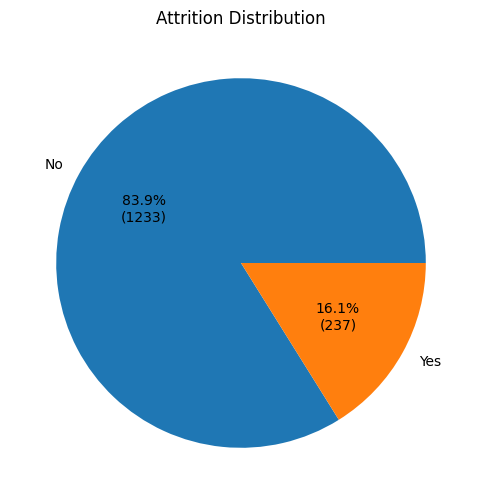

In [47]:
attrition = df.groupby('Attrition').size()

def label_fmt(pct):
    count = int(round(pct/100 * attrition.sum()))
    return f"{pct:.1f}%\n({count})"

att_plot = attrition.plot(kind='pie', autopct=label_fmt, figsize=(6, 6))
att_plot.set_ylabel('')
plt.title("Attrition Distribution")
plt.show()

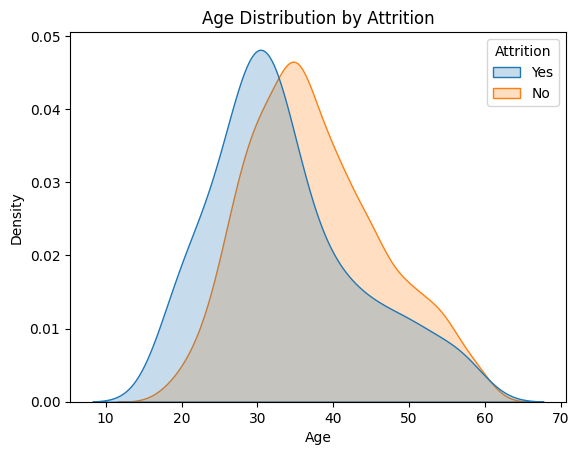

In [15]:
plt.figure()
sns.kdeplot(data=df, x="Age", hue="Attrition", fill=True, common_norm=False)
plt.title("Age Distribution by Attrition")
plt.show()

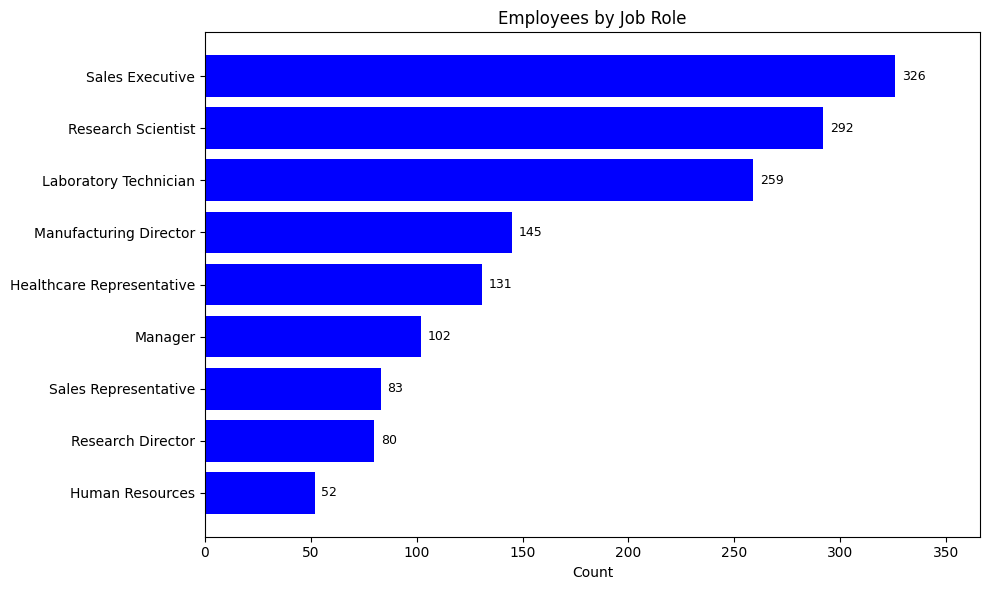

In [45]:
job_counts = df["JobRole"].value_counts().sort_values()  # sorted for a cleaner horizontal bar order

plt.figure(figsize=(10, 6))
bars = plt.barh(job_counts.index, job_counts.values, color='blue')

plt.title("Employees by Job Role")
plt.xlabel("Count")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 3, bar.get_y() + bar.get_height() / 2,
              f"{int(width)}", va="center", fontsize=9)

plt.xlim(0, job_counts.max() + 40)  # extra room so labels don't get cut off
plt.tight_layout()
plt.show()

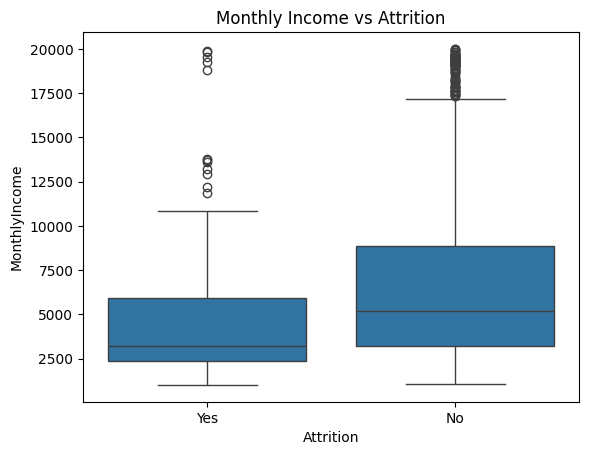

In [23]:
plt.figure()
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income vs Attrition")
plt.show()

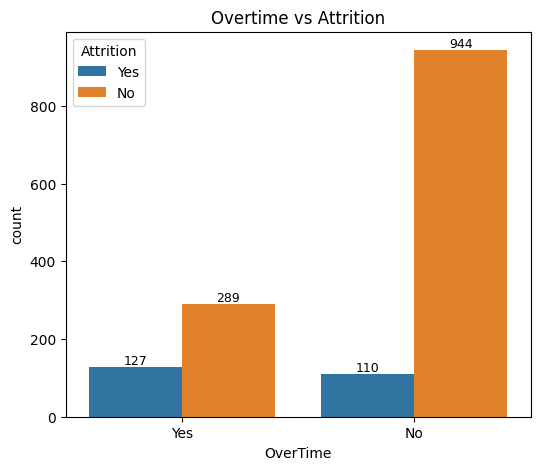

In [46]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Overtime vs Attrition")

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.show()

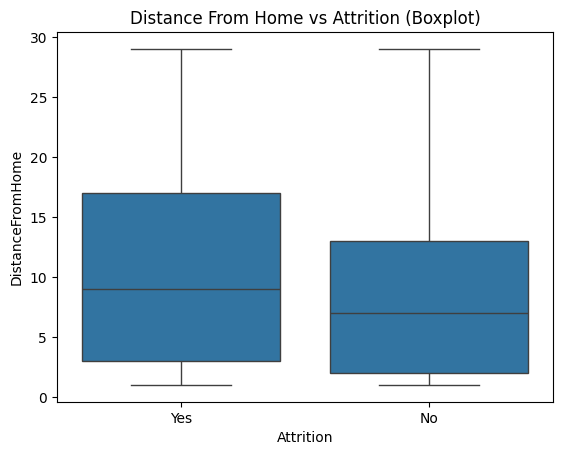

In [34]:
plt.figure()
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
plt.title("Distance From Home vs Attrition (Boxplot)")
plt.show()

In [37]:
df["WorkLifeBalance"] = df["WorkLifeBalance"].replace({
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
})

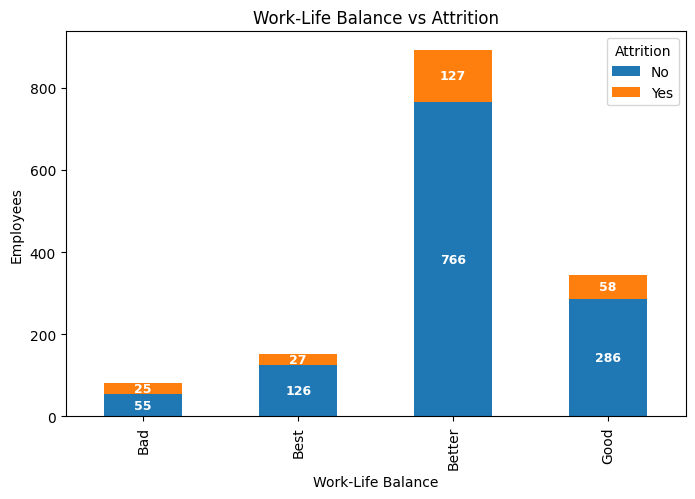

In [48]:
worklife = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"]
)

ax = worklife.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance")
plt.ylabel("Employees")

for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=9, color="white", fontweight="bold")

plt.show()

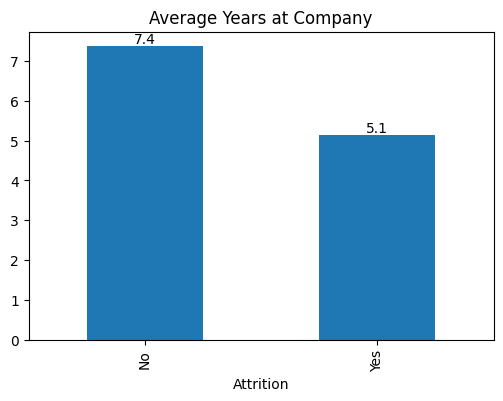

In [39]:
years = df.groupby("Attrition")["YearsAtCompany"].mean()

ax = years.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Years at Company")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

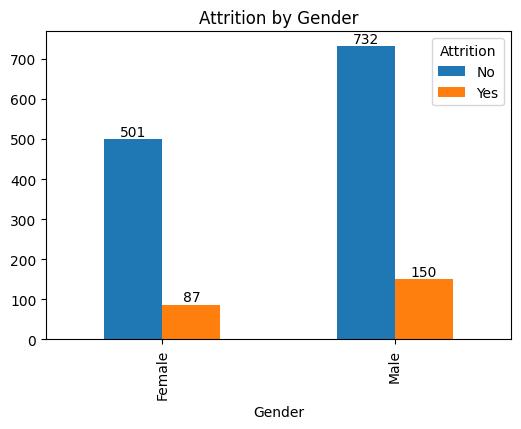

In [40]:
gender = df.groupby(["Gender", "Attrition"]).size().unstack()

ax = gender.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition by Gender")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

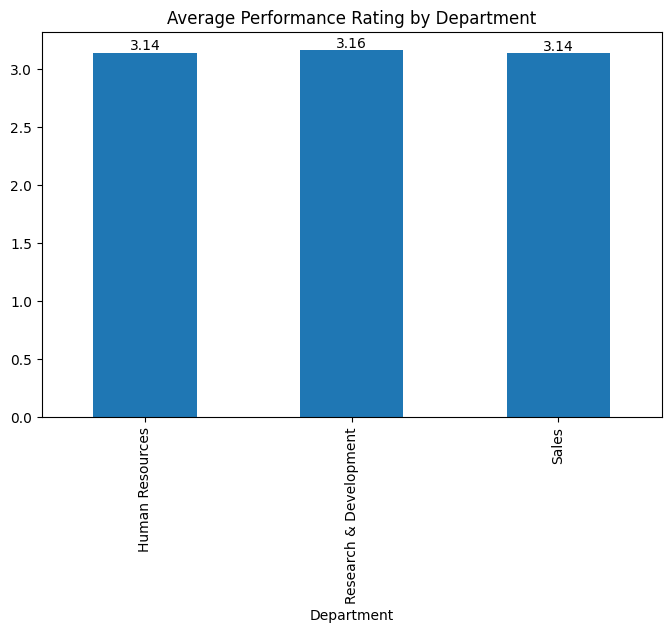

In [41]:
performance = df.groupby("Department")["PerformanceRating"].mean()

ax = performance.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Performance Rating by Department")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

In [50]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [52]:
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

In [53]:
df = pd.get_dummies(df, drop_first=True)

In [54]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8537414965986394
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       247
           1       0.83      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.84      0.55      0.55       294
weighted avg       0.85      0.85      0.80       294



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8027210884353742
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       247
           1       0.38      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.63      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294



In [59]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8401360544217688
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294

